# RecoMart - Data Cleaning & Exploratory Data Analysis

This notebook demonstrates Task 5 (Data Preparation) of the RecoMart recommendation-system pipeline:

1. Load the latest raw ingested batches (clickstream, transactions, products, sentiment)
2. Clean, encode, and normalize the data using `src/preparation/clean_and_prepare.py`
3. Explore interaction distributions, item popularity, and sparsity patterns
4. Persist the prepared datasets to `data/processed/`

All cleaning/EDA logic lives in `src/preparation/clean_and_prepare.py` so the notebook and the orchestrated pipeline (Prefect) share a single source of truth.

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(os.path.join(PROJECT_ROOT, "src", "ingestion"))
sys.path.append(os.path.join(PROJECT_ROOT, "src", "preparation"))

import pandas as pd
from IPython.display import Image, display

from common import RAW_DATA_DIR
import clean_and_prepare as prep

pd.set_option("display.max_columns", 20)

## 1. Load raw ingested data

In [2]:
raw_clickstream = prep._load_all("clickstream", "events")
raw_transactions = prep._load_all("transactions", "purchases")
raw_products = prep._load_all("products", "catalog")
raw_sentiment = prep._load_all("sentiment", "scores")

print("Raw shapes:", raw_clickstream.shape, raw_transactions.shape, raw_products.shape, raw_sentiment.shape)
raw_clickstream.head()

Raw shapes: (4000, 7) (800, 8) (40, 8) (40, 4)


,event_id,user_id,product_id,event_type,device,session_id,event_timestamp
0,78331c5b-c0df-40e0-af61-e264bd1b5251,U0381,16,click,web,3936a229-89f1-4575-b3ee-c3b576d3e7af,2026-07-14T12:24:02.208442
1,61ae308e-8253-4a1b-a78a-0e38f361a789,U0485,16,view,ios,5c94ff22-aef3-46df-9da7-214303d6ad3d,2026-07-14T12:05:32.208442
2,ad770e38-722e-42b3-8367-28135667ca87,U0357,17,view,web,8fb84bda-8283-4592-a631-7f6f911f390a,2026-07-14T12:02:17.208442
3,960088ae-82f6-43b8-9f95-359c8d9521a2,U0367,4,add_to_cart,android,c0c80327-0eb6-4eab-a288-222359ab4679,2026-07-14T12:30:24.208442
4,4708c9bc-f94a-45f1-b4c2-d3a9e35ea99d,U0270,3,view,android,733d8269-337d-4dd0-8e61-fc4567efe71f,2026-07-14T12:10:55.208442


## 2. Data cleaning

- Drop duplicate primary keys and rows with missing critical fields (`user_id`, `product_id`, ...)
- Parse and validate timestamps
- Encode categorical attributes (`event_type`, `device`, `category`) via `LabelEncoder`
- Normalize numeric attributes (`price`, `unit_price`, `total_amount`) via `MinMaxScaler`
- Flag missing explicit ratings (implicit feedback) instead of dropping the interaction

In [3]:
clickstream = prep.clean_clickstream(raw_clickstream)
transactions = prep.clean_transactions(raw_transactions)
products = prep.clean_products(raw_products)
sentiment = prep.clean_sentiment(raw_sentiment)

print("Cleaned shapes:", clickstream.shape, transactions.shape, products.shape, sentiment.shape)
transactions.head()

Cleaned shapes: (4000, 9) (800, 11) (20, 10) (20, 4)


,transaction_id,user_id,product_id,quantity,unit_price,total_amount,rating,transaction_timestamp,has_explicit_rating,unit_price_norm,total_amount_norm
0,58728273-e9e9-48ae-8680-d174c123ba20,U0144,12,2,457.48,914.96,5.0,2026-07-14 05:20:18.861115,1,0.914357,0.456144
1,876a6c83-e7e0-4510-96fb-602a869f2f53,U0037,18,4,333.13,1332.52,NaN,2026-07-14 10:53:26.861115,0,0.662769,0.665585
2,d93b67f2-ac23-4587-bd59-8bb0302fe195,U0451,10,2,269.92,539.84,NaN,2026-07-13 13:25:22.861115,0,0.534880,0.267991
3,1d8fc8e4-24aa-479f-b9c0-b9aea3b59348,U0388,2,1,44.37,44.37,3.0,2026-07-13 16:37:01.861115,1,0.078542,0.019471
4,0a848f09-6cf4-4433-b08f-5b2e093e6f9b,U0148,7,2,112.63,225.26,4.0,2026-07-13 19:45:36.861115,1,0.216647,0.110203


## 3. Exploratory Data Analysis

Generates and saves summary plots to `reports/eda_plots/`: event-type distribution, item popularity, user-item sparsity, rating distribution, and average price by category.

In [4]:
stats = prep.run_eda(clickstream, transactions, products)
stats

2026-07-14 18:24:45,344 | INFO     | preparation | EDA complete: users=498 items=20 interactions=3277 sparsity=0.6710


{'n_users': 498,
 'n_items': 20,
 'n_interactions': 3277,
 'sparsity': 0.6709839357429719}

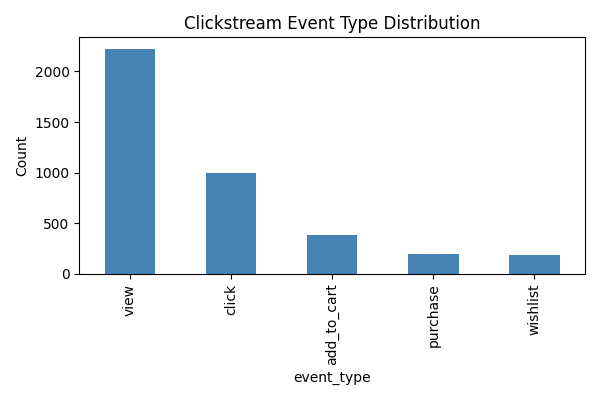

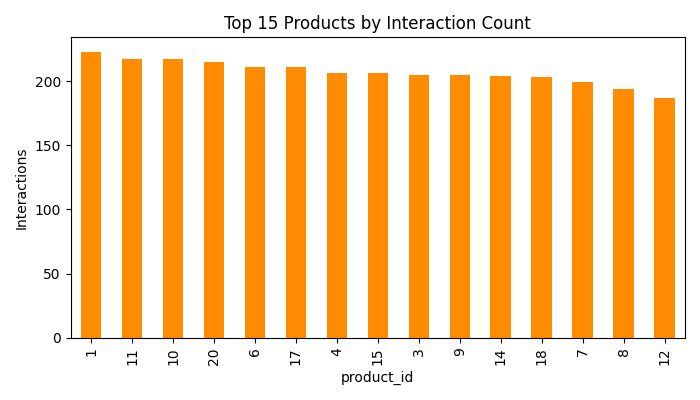

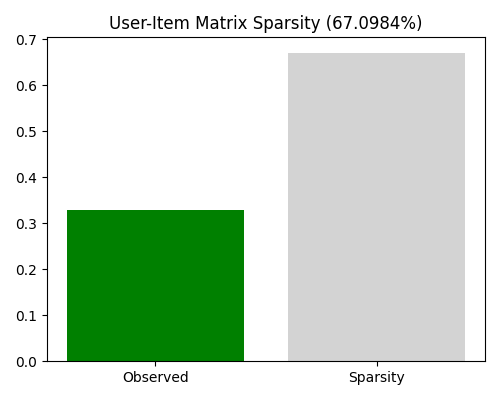

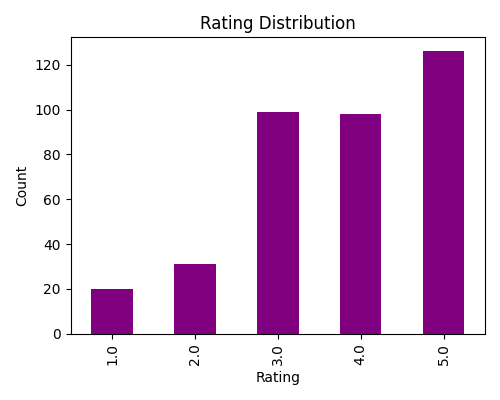

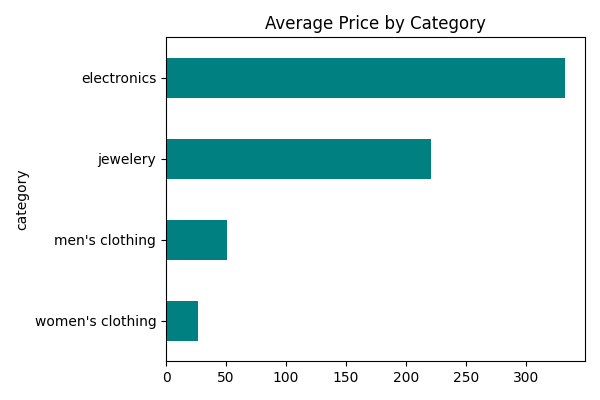

In [5]:
for fname in ["event_type_distribution.png", "item_popularity.png", "sparsity.png", "rating_distribution.png", "avg_price_by_category.png"]:
    display(Image(filename=os.path.join(prep.PLOTS_DIR, fname)))

## 4. Persist prepared datasets

Writes the cleaned/encoded/normalized datasets to `data/processed/`, ready for the transformation (feature engineering) stage.

In [6]:
clickstream.to_csv(os.path.join(prep.PROCESSED_DIR, "clickstream_clean.csv"), index=False)
transactions.to_csv(os.path.join(prep.PROCESSED_DIR, "transactions_clean.csv"), index=False)
products.to_csv(os.path.join(prep.PROCESSED_DIR, "products_clean.csv"), index=False)
sentiment.to_csv(os.path.join(prep.PROCESSED_DIR, "sentiment_clean.csv"), index=False)
print("Prepared datasets written to", prep.PROCESSED_DIR)

Prepared datasets written to C:\Darshan\DMML\data\processed
